In this file we explore the esr data as the first step towards modeling

In [1]:
#import modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [2]:
fpath_ = './saved_data/svd_matrix_sensor1/*'

files = glob.glob(fpath_)

<Axes: >

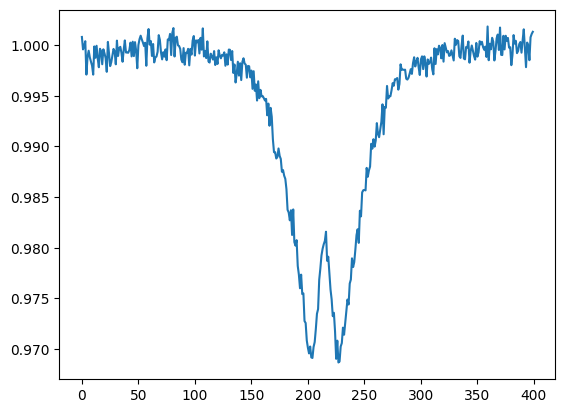

In [3]:
dfg = pd.read_csv(files[0])
dfg.iloc[:, 2:].mean(axis=1).plot()

In [4]:
temp_data = ['./saved_data/svd_matrix_sensor1\\minus30c_401_datapoints',
     './saved_data/svd_matrix_sensor1\\15c_401_datapoints',
     './saved_data/svd_matrix_sensor1\\25c_401_datapoints',
     './saved_data/svd_matrix_sensor1\\30c_401_datapoints',
     './saved_data/svd_matrix_sensor1\\40c_401_datapoints',
     './saved_data/svd_matrix_sensor1\\70c_401_datapoints',
     './saved_data/svd_matrix_sensor1\\40c_401_datapoints_after70C_minus10dbm_60percent_laser',
     './saved_data/svd_matrix_sensor1\\25c_return_401_datapoints',
     './saved_data/svd_matrix_sensor1\\10C_401_datapoints_after_70C_minus10dbm_60percent_laser',
     './saved_data/svd_matrix_sensor1\\minus30c_401_datapoints_after_70C_minus10dbm_60percent_laser'
]

temp = [-30, 15, 25, 30, 40, 70, 40, 25, 10, -30]

data_density = [ './saved_data/svd_matrix_sensor1\\15c_201_points',
          './saved_data/svd_matrix_sensor1\\15c_401_datapoints',
          './saved_data/svd_matrix_sensor1\\25c_101_datapoints',
          './saved_data/svd_matrix_sensor1\\25c_201_datapoints',
          './saved_data/svd_matrix_sensor1\\25c_401_datapoints',
]

density = ['15C_201', '15C_401', '25C_101', '25C_201', '25C_401' ]

mw_laser_power = [  './saved_data/svd_matrix_sensor1\\10C_401_datapoints_after_70C_minus10dbm_90percent_laser',
    './saved_data/svd_matrix_sensor1\\25c_401_datapoints_after_70C_0dbm', 
    './saved_data/svd_matrix_sensor1\\25c_401_datapoints_after_70C_minus5dbm',
    './saved_data/svd_matrix_sensor1\\25c_401_datapoints_after_70C_minus10dbm_90_percent_laser_power',
    './saved_data/svd_matrix_sensor1\\40c_401_datapoints_after70C_0dbm_60percent_laser',
]

mwlp = ['10C_-10dbm_90lp', '25C_0dbm_60lp', '25C_-5dbm_60lp', '25C_-10dbm_90lp', '25C_0dbm_60lp' ]

In [5]:
df_temp = pd.DataFrame(dfg.iloc[:,1].values) 
df_temp.columns=['Frequency']

-30


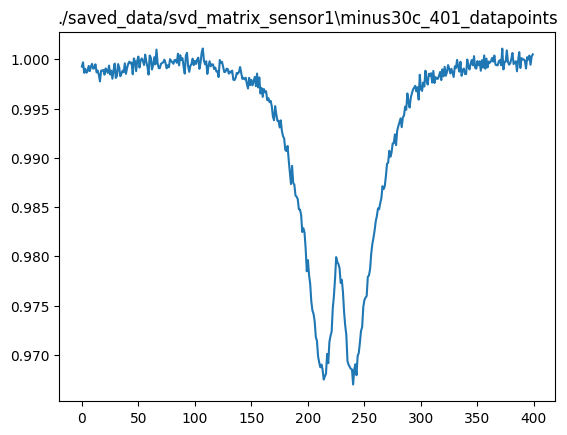

15


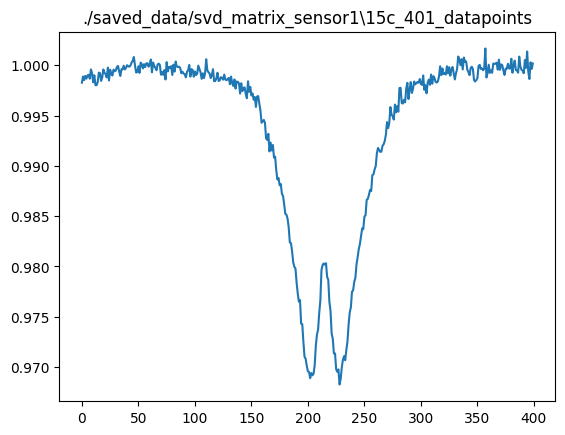

25


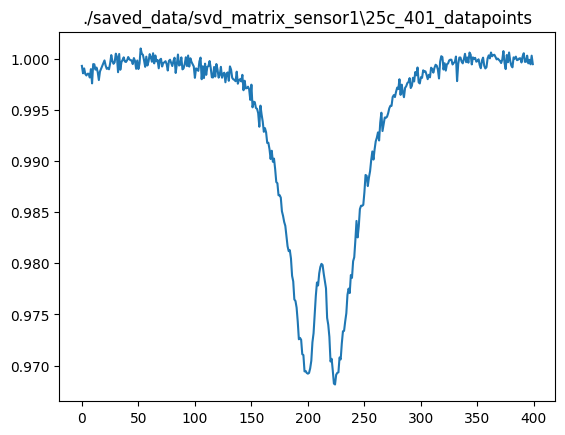

30


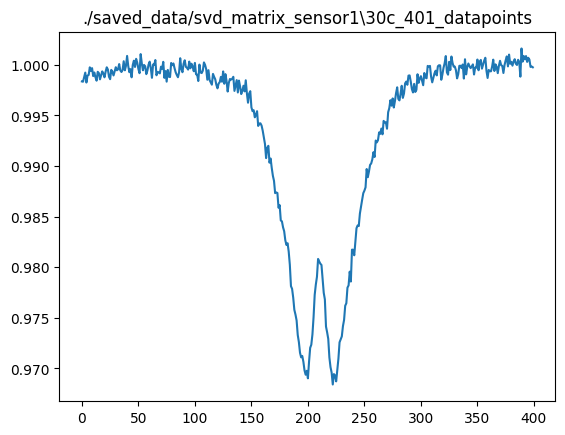

40


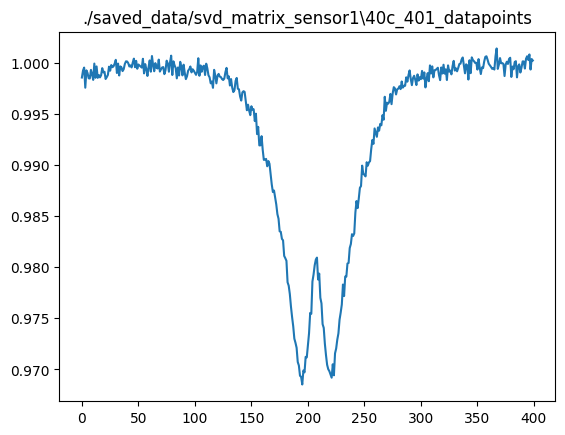

70


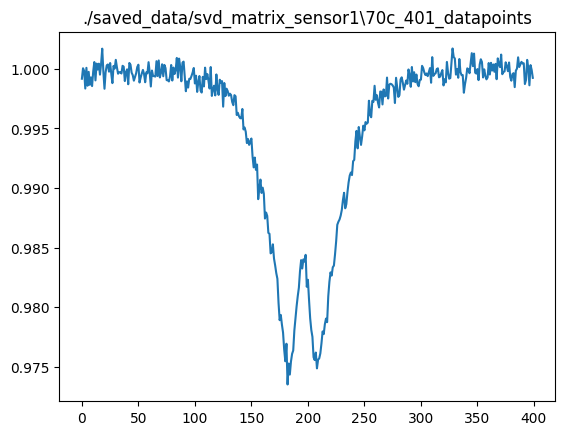

40


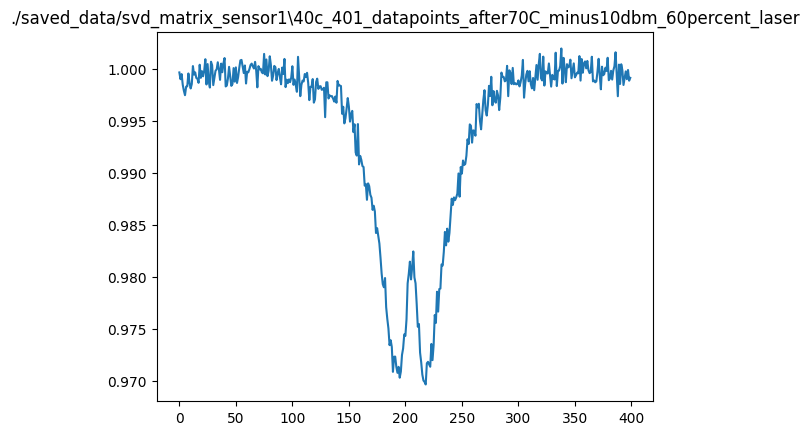

25


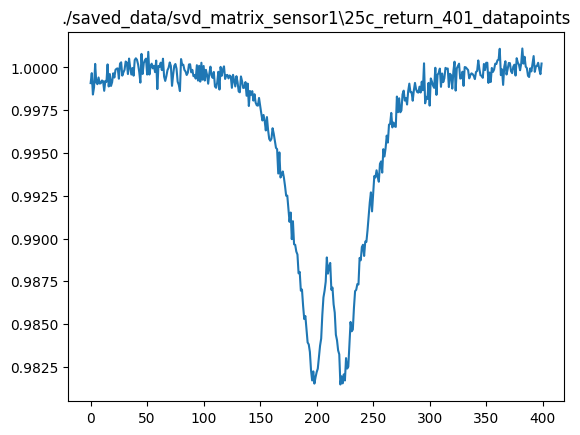

10


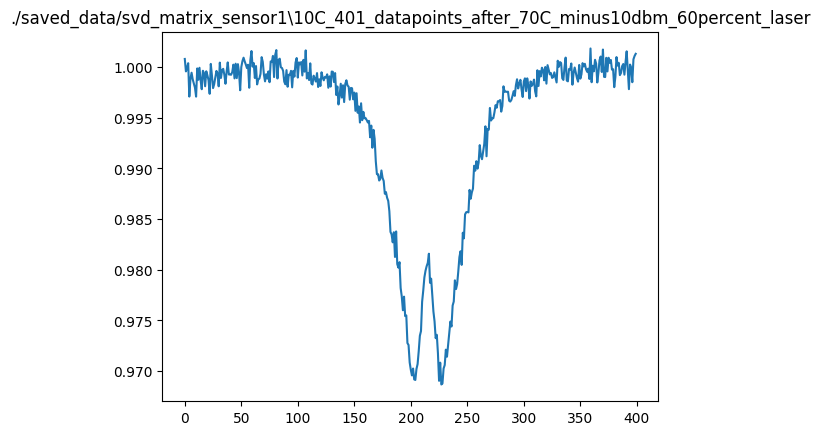

-30


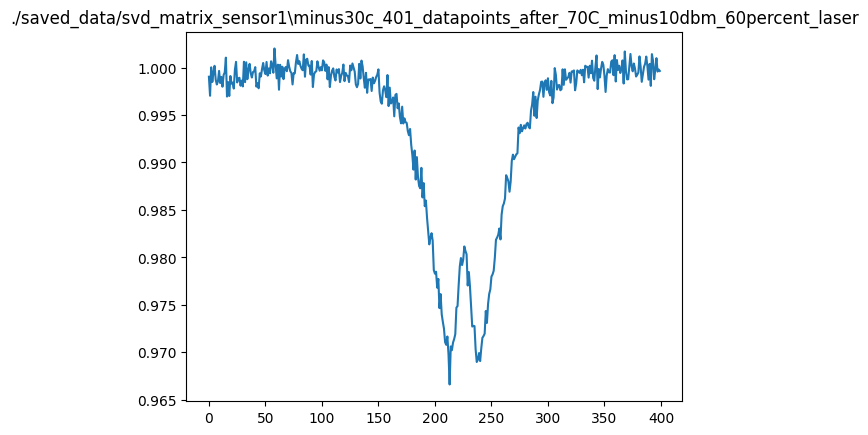

In [6]:
#generatre temp cycling data matrix
for j, i in enumerate(temp_data):
    if '_401_' in i:
        df_ = pd.read_csv(i, sep=',', header =0)
        df_mean = df_.iloc[:, 2:].mean(axis=1)
        df_mean.columns = [temp[j]]
        print(temp[j])
        df_mean.plot()
        df_temp = pd.concat([df_temp, df_mean], axis=1)
        plt.title(i)
        plt.show()
    else:
        print('pass')
df_temp.columns = ['frequency']+ temp
df_temp.to_csv('./saved_data/cycle3')

15C_201


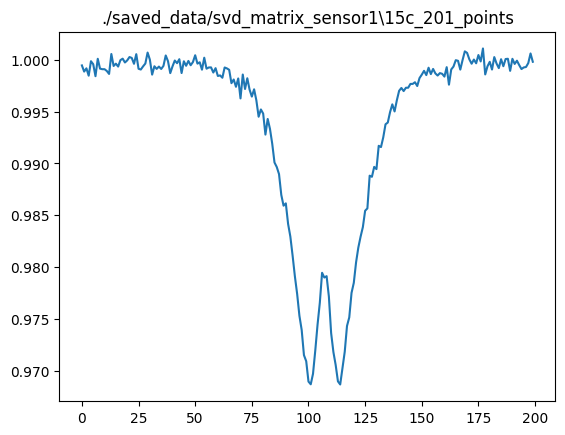

15C_401


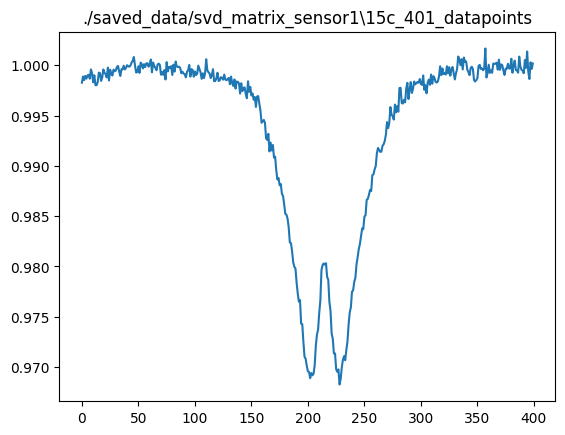

25C_101


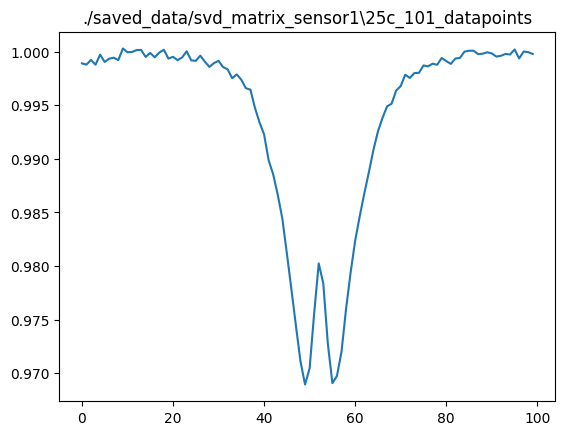

25C_201


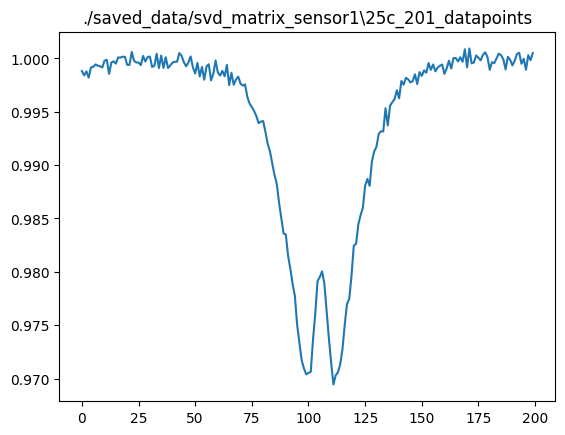

25C_401


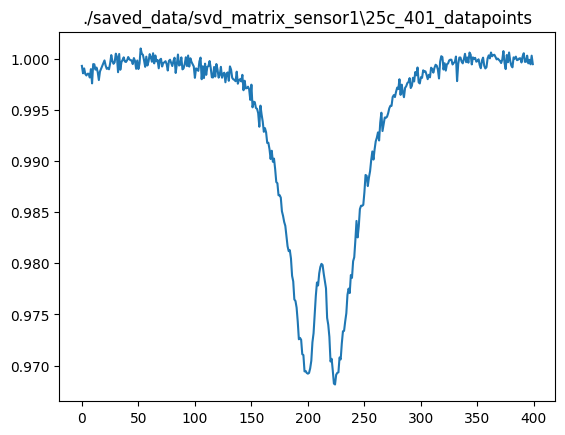

In [7]:
# define empty holder with frequency data
df_density = pd.DataFrame(dfg.iloc[:,1].values) 
df_density.columns=['Frequency']

#generatre data density dependence data matrix
for j, i in enumerate(data_density):
    df_ = pd.read_csv(i, sep=',', header =0)
    df_mean = df_.iloc[:, 2:].mean(axis=1)
    df_mean.columns = [density[j]]
    print(density[j])
    df_mean.plot()
    df_density = pd.concat([df_density, df_mean], axis=1)
    plt.title(i)
    plt.show()
    
df_density.columns = ['frequency']+ density
df_density.to_csv('./saved_data/cycle3_data_density')

10C_-10dbm_90lp


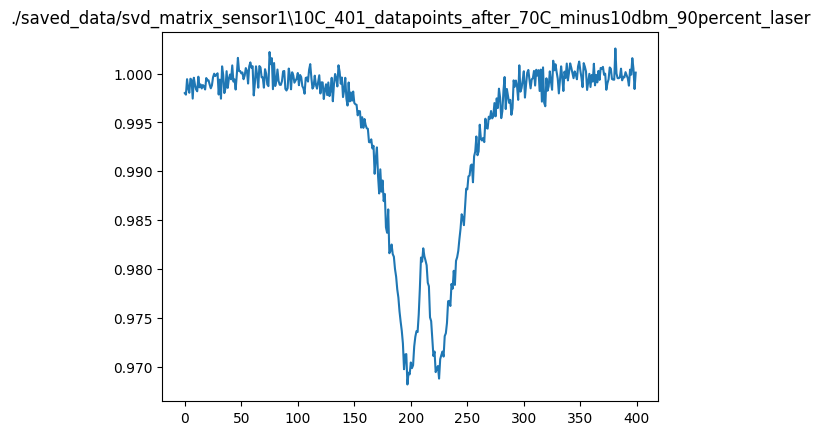

25C_0dbm_60lp


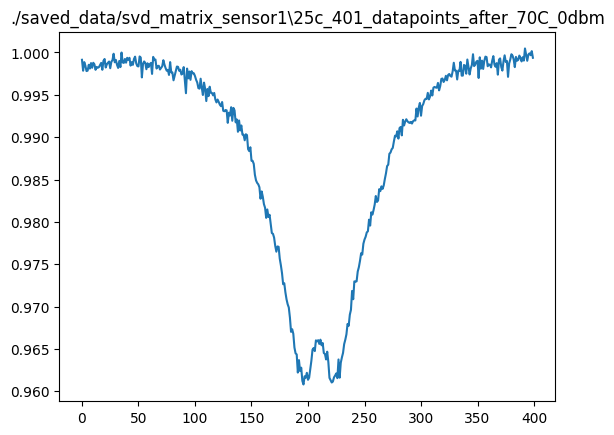

25C_-5dbm_60lp


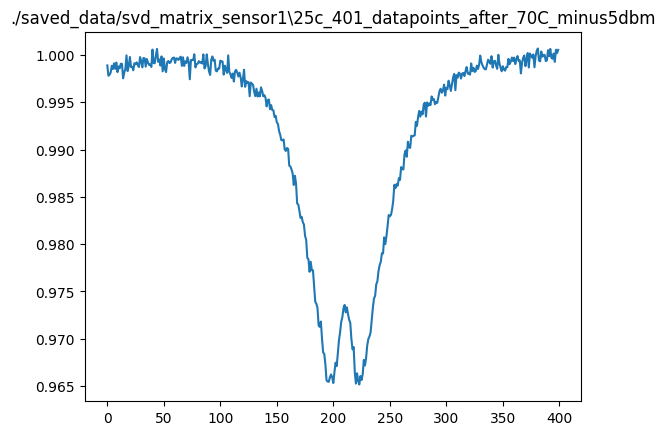

25C_-10dbm_90lp


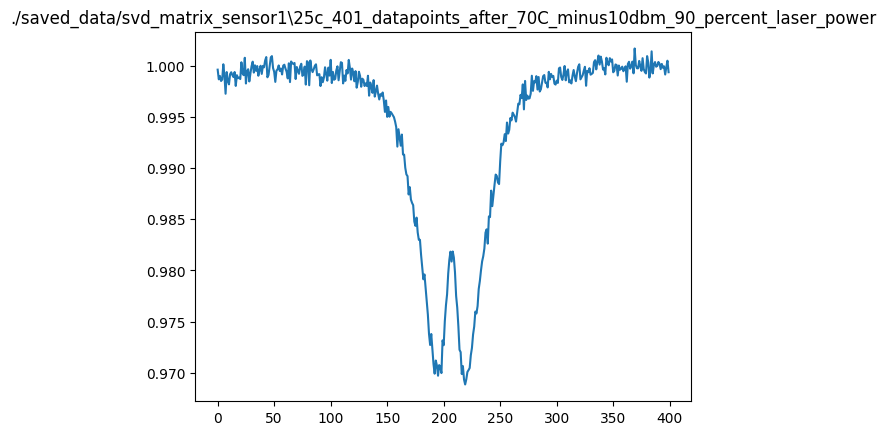

25C_0dbm_60lp


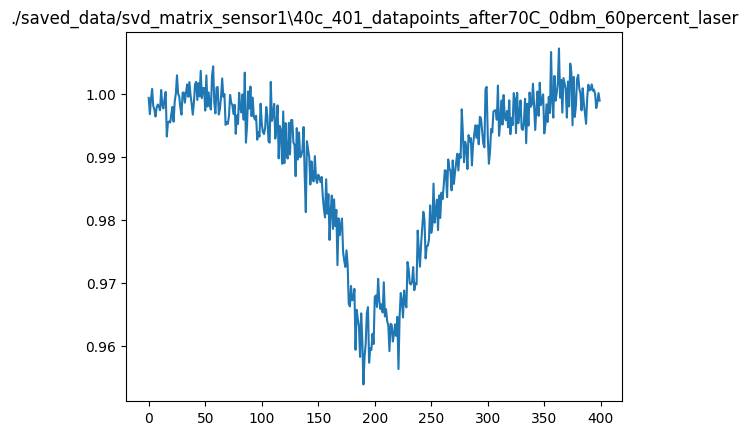

In [8]:
# define empty holder with mw and laser power dependence data
df_mw = pd.DataFrame(dfg.iloc[:,1].values) 
df_mw.columns=['Frequency']

#generatre data density dependence data matrix
for j, i in enumerate(mw_laser_power):
    df_ = pd.read_csv(i, sep=',', header =0)
    df_mean = df_.iloc[:, 2:].mean(axis=1)
    df_mean.columns = [mwlp[j]]
    print(mwlp[j])
    df_mean.plot()
    df_mw = pd.concat([df_mw, df_mean], axis=1)
    plt.title(i)
    plt.show()

df_mw.columns = ['frequency']+ density
df_mw.to_csv('./saved_data/cycle3_lp_mw_dependence')